Imports, seed et vérification de cuda

In [1]:
# ==========================================
# CELLULE 1 : IMPORTS ET CONFIGURATION
# ==========================================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

# Imports de l'architecture Zoidberg
from src.data import Lungdataset, get_train_transforms, get_val_transforms
from src.models import get_model
from src.training import train_one_epoch, validate, compute_class_weights, EarlyStopper

# --- 1. CONFIGURATION MATÉRIELLE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device actif : {device}")

# --- 2. FONCTION DE REPRODUCTIBILITÉ ---
def set_seed(seed=42):
    """Verrouille toutes les sources d'aléatoire."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"🔒 Seed fixé à {seed} : Expériences 100% reproductibles !")

# On applique le seed globalement
set_seed(42)

# --- 3. CONSTANTES DU PROJET ---
BATCH_SIZE = 16
TRAIN_DIR = "data/raw/train"
VAL_DIR = "data/raw/test"
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True) # Création du dossier de sauvegarde au cas où

🚀 Device actif : cuda
🔒 Seed fixé à 42 : Expériences 100% reproductibles !


Chargement des données du sampler

In [2]:
# ==========================================
# CELLULE 2 : DATASETS ET DATALOADERS
# ==========================================

# --- 1. SÉCURITÉ DES WORKERS (Reproductibilité) ---
def _seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Générateur PyTorch verrouillé
g = torch.Generator()
g.manual_seed(42)

# --- 2. CHARGEMENT DES DATASETS ---
train_ds = Lungdataset(root_dir=TRAIN_DIR, transform=get_train_transforms())
val_ds = Lungdataset(root_dir=VAL_DIR, transform=get_val_transforms())

# --- 3. GESTION DU DÉSÉQUILIBRE (Poids des classes) ---
class_weights = compute_class_weights(train_ds)
class_weights[0] *= 1.1  # Léger boost sur la classe "Normal" pour limiter les faux positifs
class_weights = class_weights.to(device)

print(f"⚖️ Poids des classes : Normal={class_weights[0]:.2f}, Viral={class_weights[1]:.2f}, Bactérien={class_weights[2]:.2f}")

# --- 4. SAMPLER (Équilibrage des batchs) ---
sample_weights = [class_weights[label].item() for _, label in train_ds.samples]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True,
    generator=g
)

# --- 5. DATALOADERS ---
train_loader = torch.utils.data.DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    sampler=sampler, 
    num_workers=4,
    worker_init_fn=_seed_worker,
    generator=g
)

val_loader = torch.utils.data.DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    worker_init_fn=_seed_worker
)

print(f"📊 Données prêtes : {len(train_ds)} images d'entraînement | {len(val_ds)} images de validation")

⚖️ Poids des classes : Normal=1.43, Viral=1.29, Bactérien=0.69
📊 Données prêtes : 5216 images d'entraînement | 624 images de validation


Phase de test 1

In [3]:
# ==========================================
# CELLULE 3 : ENTRAÎNEMENT PHASE 1 (LINEAR PROBING)
# ==========================================

# 1. On re-fixe le seed pour garantir que l'initialisation des poids 
#    de la nouvelle tête de classification sera toujours la même.
set_seed(42)

print("⏳ Chargement du modèle DenseNet121 (Phase 1)...")
# Phase 1 : Backbone 100% gelé, seul le classifieur est actif
model_p1 = get_model("densenet121", num_classes=3, phase=1).to(device)

# Vérification des paramètres
trainable = sum(p.numel() for p in model_p1.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_p1.parameters())
print(f"🧠 Params entraînables : {trainable:,} / {total:,} ({(trainable/total)*100:.2f}%)")

# 2. Configuration de l'entraînement (Phase 1)
# On garde un Learning Rate assez haut (1e-3) car on n'entraîne qu'une seule couche
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer_p1 = optim.Adam(filter(lambda p: p.requires_grad, model_p1.parameters()), lr=1e-3)

EPOCHS_PHASE_1 = 10
best_val_acc_p1 = 0.0
best_model_path_p1 = "models/temp_phase1.pth"

print(f"\n▶️ Lancement de {EPOCHS_PHASE_1} époques de test (Phase 1)...")

# 3. Boucle d'entraînement
for epoch in range(EPOCHS_PHASE_1):
    # Entraînement (Mixup désactivé en Phase 1 pour bien caler les bases)
    train_loss = train_one_epoch(
        model_p1, train_loader, criterion, optimizer_p1, device, 
        use_mixup=False, grad_accum_steps=2
    )
    
    # Validation
    val_loss, val_acc = validate(model_p1, val_loader, criterion, device)
    
    print(f"Epoch {epoch+1}/{EPOCHS_PHASE_1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    # Sauvegarde du meilleur modèle de la Phase 1
    if val_acc > best_val_acc_p1:
        best_val_acc_p1 = val_acc
        torch.save(model_p1.state_dict(), best_model_path_p1)
        print("   🌟 Nouveau record Phase 1 sauvegardé !")

print("\n✅ Phase 1 terminée. Le modèle est prêt pour le fine-tuning.")

🔒 Seed fixé à 42 : Expériences 100% reproductibles !
⏳ Chargement du modèle DenseNet121 (Phase 1)...
🧠 Params entraînables : 3,075 / 6,956,931 (0.04%)

▶️ Lancement de 10 époques de test (Phase 1)...
Epoch 1/10 | Train Loss: 0.7715 | Val Loss: 0.6776 | Val Acc: 73.40%
   🌟 Nouveau record Phase 1 sauvegardé !
Epoch 2/10 | Train Loss: 0.6095 | Val Loss: 0.6842 | Val Acc: 65.71%
Epoch 3/10 | Train Loss: 0.5988 | Val Loss: 0.6784 | Val Acc: 68.75%
Epoch 4/10 | Train Loss: 0.6098 | Val Loss: 0.6674 | Val Acc: 75.32%
   🌟 Nouveau record Phase 1 sauvegardé !
Epoch 5/10 | Train Loss: 0.6051 | Val Loss: 0.6157 | Val Acc: 82.53%
   🌟 Nouveau record Phase 1 sauvegardé !
Epoch 6/10 | Train Loss: 0.5760 | Val Loss: 0.7945 | Val Acc: 54.49%
Epoch 7/10 | Train Loss: 0.5748 | Val Loss: 0.6109 | Val Acc: 79.01%
Epoch 8/10 | Train Loss: 0.5860 | Val Loss: 0.6655 | Val Acc: 72.76%
Epoch 9/10 | Train Loss: 0.5821 | Val Loss: 0.6316 | Val Acc: 82.53%
Epoch 10/10 | Train Loss: 0.5830 | Val Loss: 0.6050 | Va

Phase 2 : Entrainement des dernières couches (avec degel)

In [12]:
# ==========================================
# CELLULE 4 : ENTRAÎNEMENT PHASE 2 (FINE-TUNING PARTIEL)
# ==========================================

# 1. On re-fixe l'aléatoire
set_seed(42)

print("⏳ Chargement du modèle DenseNet121 (Phase 2)...")
# En Phase 2, registry.py dégèle 'transition3' et 'denseblock4'
model_p2 = get_model("densenet121", num_classes=3, phase=2).to(device)

# 2. On charge le record de la Phase 1 (le socle à 73%)
model_p2.load_state_dict(torch.load("models/temp_phase1.pth", map_location=device, weights_only=True))
print("✅ Poids de la Phase 1 chargés avec succès !")

# Vérification : Tu vas voir que le % de paramètres entraînables a beaucoup augmenté !
trainable = sum(p.numel() for p in model_p2.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_p2.parameters())
print(f"🧠 Params entraînables (Phase 2) : {trainable:,} / {total:,} ({(trainable/total)*100:.2f}%)")

# 3. Séparation des paramètres pour le Discriminative Learning Rate
head_params = []
backbone_params = []
for name, param in model_p2.named_parameters():
    if not param.requires_grad:
        continue
    if "classifier" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

# 4. Optimiseur "Chirurgical"
optimizer_p2 = optim.Adam([
    {"params": backbone_params, "lr": 1e-5}, # LR très faible pour le corps
    {"params": head_params, "lr": 1e-4}      # LR moyen pour la tête
], weight_decay=1e-4)

# Le CosineAnnealing va doucement réduire le LR à chaque époque pour atterrir en douceur
scheduler = CosineAnnealingLR(optimizer_p2, T_max=50, eta_min=1e-7)

EPOCHS_PHASE_2 = 50
best_val_acc_p2 = 0.0
best_model_path_p2 = "models/densenet121_final.pth"

from src.training import EarlyStopper
early_stopper = EarlyStopper(patience=10, min_delta=0.0)

print(f"\n▶️ Lancement de {EPOCHS_PHASE_2} époques de Fine-Tuning (Phase 2)...")

# 5. Boucle d'entraînement
for epoch in range(EPOCHS_PHASE_2):
    current_lr = optimizer_p2.param_groups[0]["lr"] # On affiche le LR du backbone
    
    # ⚠️ Changement majeur : on active le MIXUP (use_mixup=True) pour éviter l'overfitting
    train_loss = train_one_epoch(
        model_p2, train_loader, criterion, optimizer_p2, device, 
        use_mixup=True, mixup_alpha=0.2, grad_accum_steps=2
    )
    
    scheduler.step() # On baisse légèrement le LR pour la prochaine époque
    
    # Validation
    val_loss, val_acc = validate(model_p2, val_loader, criterion, device)
    
    print(f"Epoch {epoch+1}/{EPOCHS_PHASE_2} (LR: {current_lr:.2e}) | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    # Sauvegarde du record
    if val_acc > best_val_acc_p2:
        best_val_acc_p2 = val_acc
        torch.save(model_p2.state_dict(), best_model_path_p2)
        print("   🌟 Nouveau record absolu sauvegardé !")

    early_stopper(val_loss)
    if early_stopper.early_stop:
        print(f"\n⏹️ Early Stopping déclenché à l'époque {epoch+1} ! Le modèle ne s'améliore plus.")
        break

# On recharge le meilleur modèle à la fin
print(f"\n✅ Fine-Tuning terminé. Rechargement du modèle record ({best_val_acc_p2*100:.2f}%)...")
model_p2.load_state_dict(torch.load(best_model_path_p2, map_location=device, weights_only=True))
print("🏁 Modèle final prêt pour l'évaluation clinique !")

🔒 Seed fixé à 42 : Expériences 100% reproductibles !
⏳ Chargement du modèle DenseNet121 (Phase 2)...
✅ Poids de la Phase 1 chargés avec succès !
🧠 Params entraînables (Phase 2) : 2,657,283 / 6,956,931 (38.20%)

▶️ Lancement de 50 époques de Fine-Tuning (Phase 2)...
Epoch 1/50 (LR: 1.00e-05) | Train Loss: 0.6686 | Val Loss: 0.6544 | Val Acc: 78.69%
   🌟 Nouveau record absolu sauvegardé !
Epoch 2/50 (LR: 9.99e-06) | Train Loss: 0.6545 | Val Loss: 0.7067 | Val Acc: 67.95%
Epoch 3/50 (LR: 9.96e-06) | Train Loss: 0.6375 | Val Loss: 0.6563 | Val Acc: 75.16%
Epoch 4/50 (LR: 9.91e-06) | Train Loss: 0.6105 | Val Loss: 0.6485 | Val Acc: 77.24%
Epoch 5/50 (LR: 9.84e-06) | Train Loss: 0.6124 | Val Loss: 0.6467 | Val Acc: 77.56%
Epoch 6/50 (LR: 9.76e-06) | Train Loss: 0.5944 | Val Loss: 0.7314 | Val Acc: 72.12%
Epoch 7/50 (LR: 9.65e-06) | Train Loss: 0.6226 | Val Loss: 0.6250 | Val Acc: 78.37%
Epoch 8/50 (LR: 9.53e-06) | Train Loss: 0.5804 | Val Loss: 0.6439 | Val Acc: 78.85%
   🌟 Nouveau record ab

In [13]:
Evaluation clinique

SyntaxError: invalid syntax (155727970.py, line 1)

⏳ Chargement du modèle Champion (Phase 1)...

📊 1. ÉVALUATION CLINIQUE ET MATRICE DE CONFUSION


╔══════════════════════════════════════╗
║      BILAN D'ÉVALUATION CLINIQUE     ║
╚══════════════════════════════════════╝

Précision globale : 82.53%

Matrice de confusion :
                  Normal       Viral   Bactérien
      Normal         186          46           2
       Viral           6         124          18
   Bactérien          12          25         205

Rapport détaillé :
              precision    recall  f1-score   support

      Normal     0.9118    0.7949    0.8493       234
       Viral     0.6359    0.8378    0.7230       148
   Bactérien     0.9111    0.8471    0.8779       242

    accuracy                         0.8253       624
   macro avg     0.8196    0.8266    0.8168       624
weighted avg     0.8461    0.8253    0.8305       624

  📊 Heatmap sauvegardée → results/confusion_densenet121_clahe_phase1.png

Matrice de confusion générée :


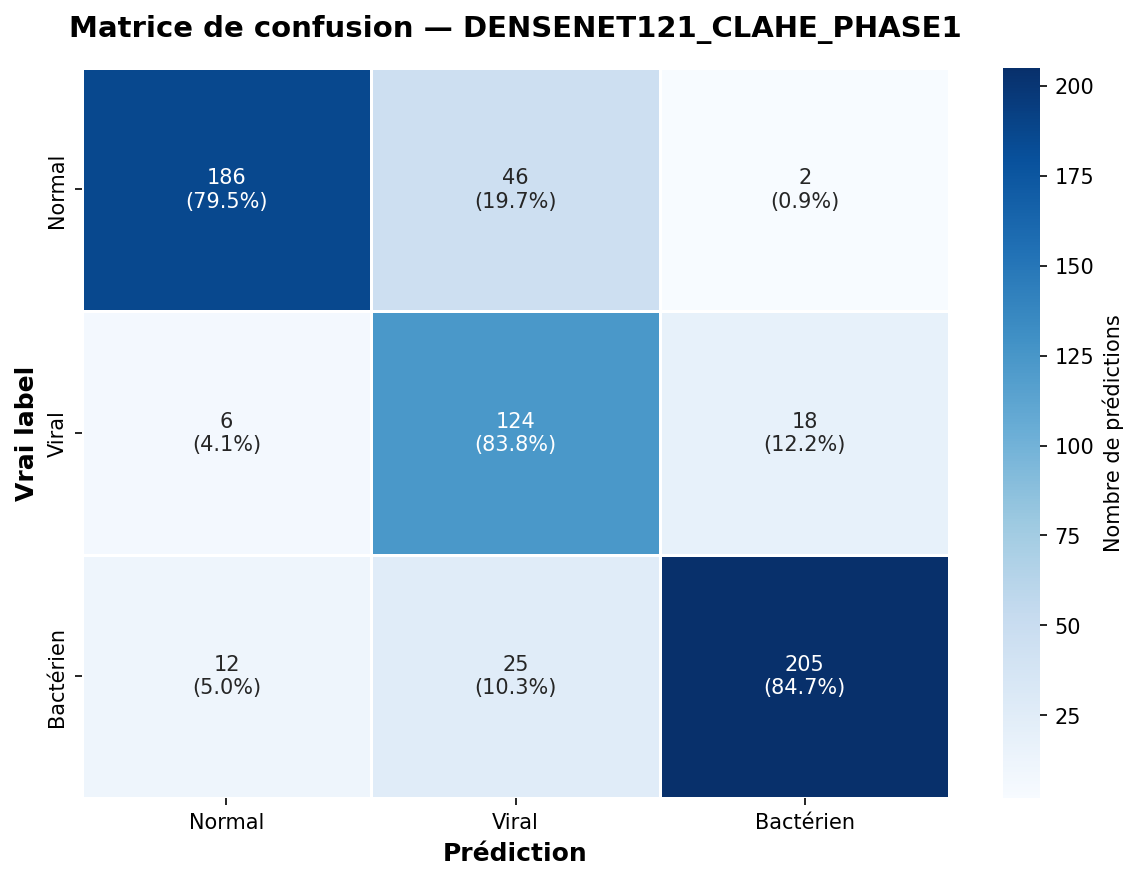


🧐 2. ANALYSE DES PIRES ERREURS (MUR DES ERREURS)

Mur des erreurs généré :


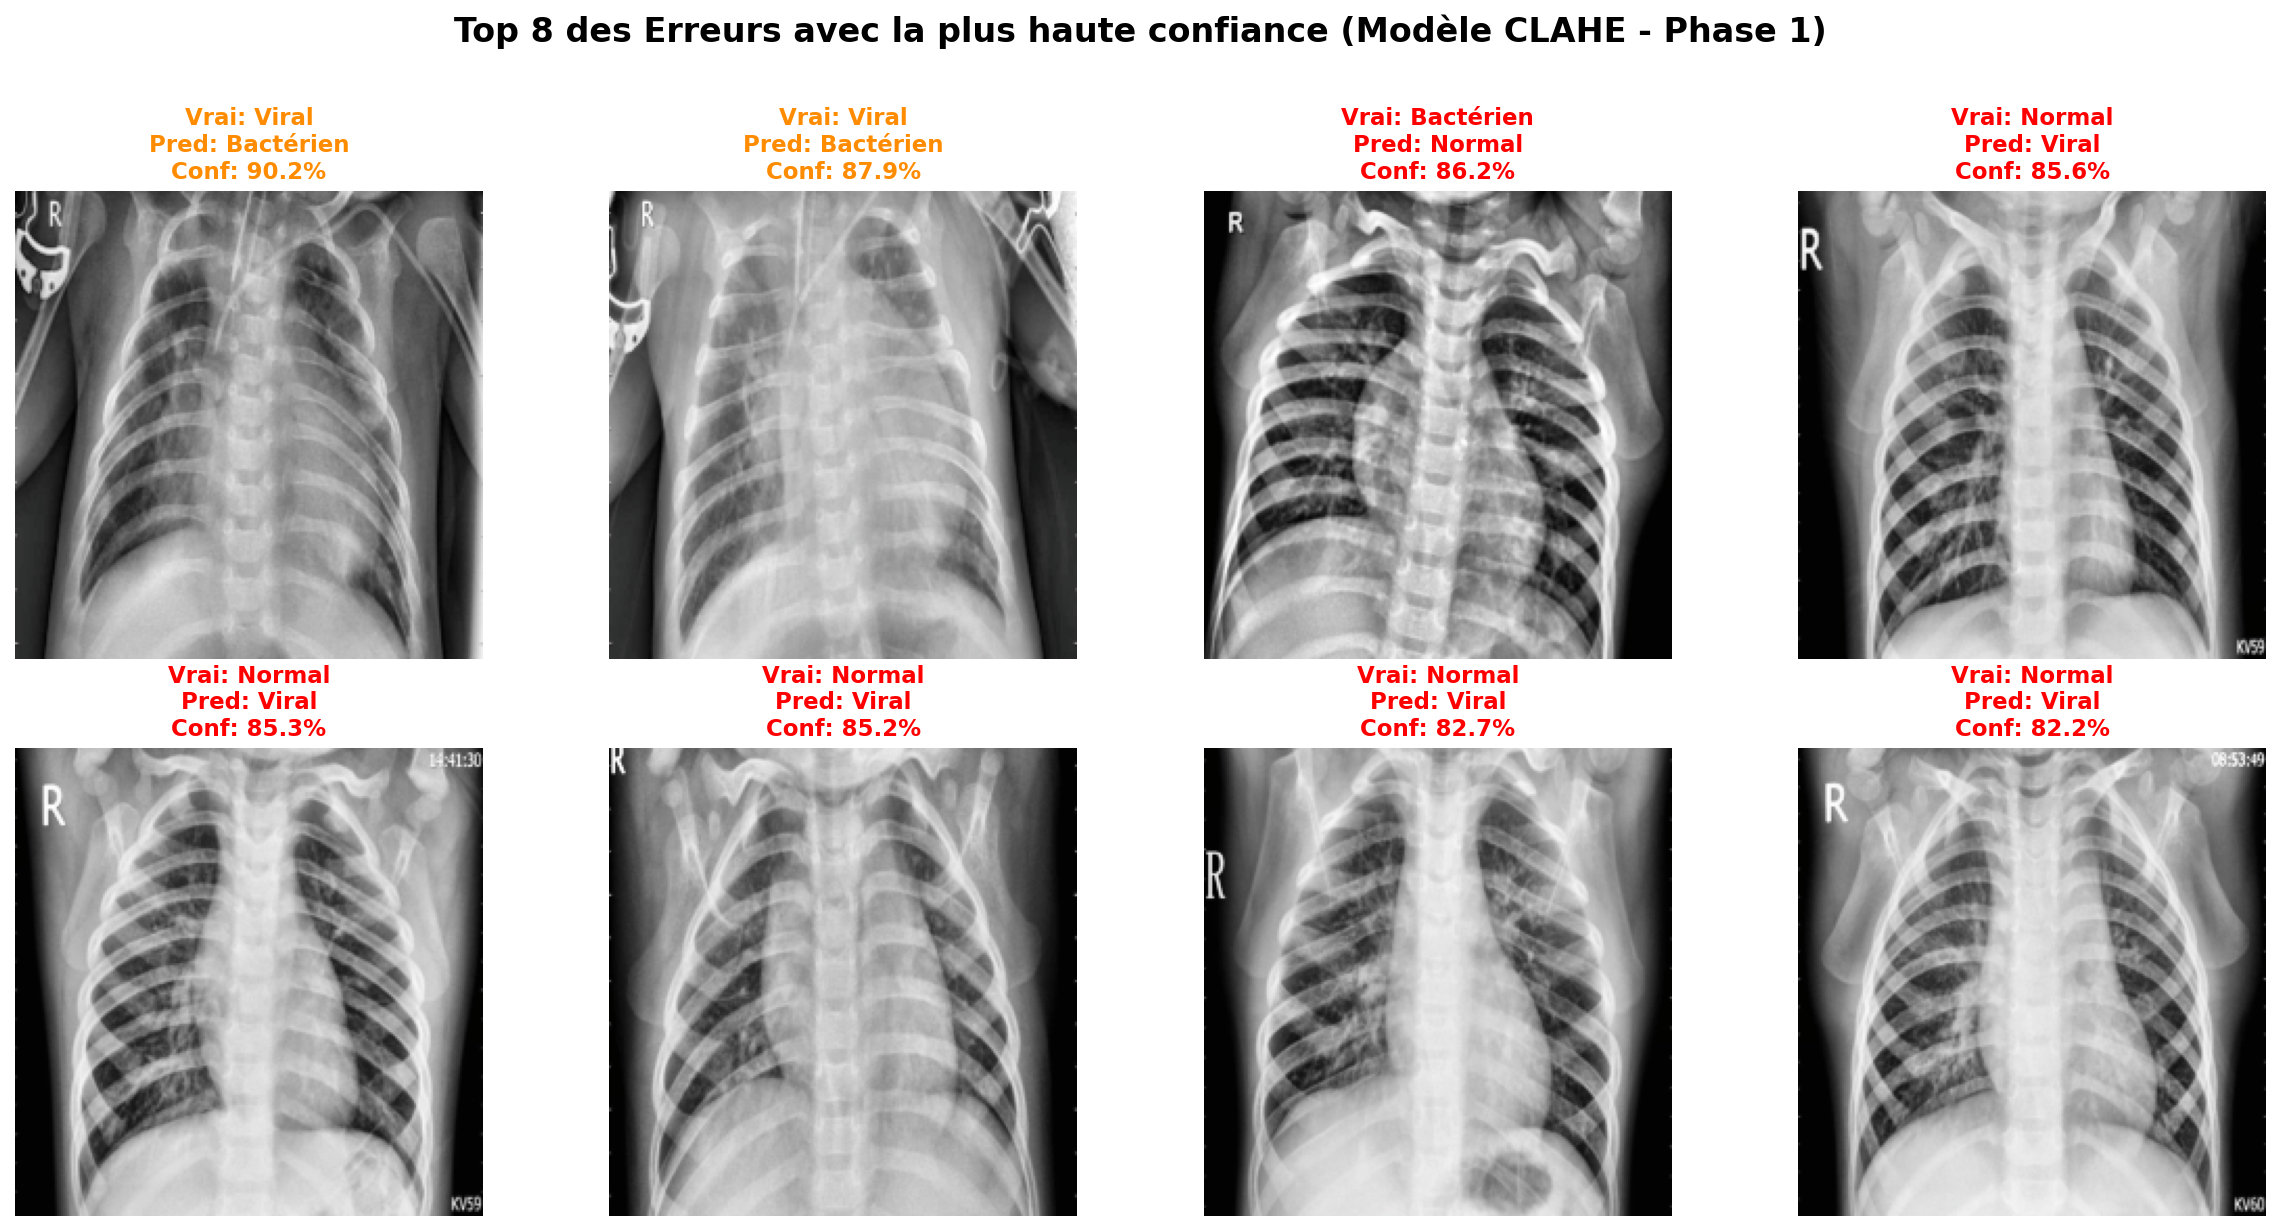

In [14]:
# ==========================================
# CELLULE 5 : ÉVALUATION DU CHAMPION (PHASE 1)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from IPython.display import Image, display
from src.training.evaluate import evaluate_model, CLASSES
from src.models import get_model

print("⏳ Chargement du modèle Champion (Phase 1)...")
# On charge une architecture Phase 1
champion_model = get_model("densenet121", num_classes=3, phase=1).to(device)
# On lui injecte les poids du record à 82.53%
champion_model.load_state_dict(torch.load("models/temp_phase1.pth", map_location=device, weights_only=True))

print("\n📊 1. ÉVALUATION CLINIQUE ET MATRICE DE CONFUSION\n")
results = evaluate_model(champion_model, val_loader, device, model_name="densenet121_clahe_phase1")

# Afficher la heatmap
print("\nMatrice de confusion générée :")
display(Image(filename=results['heatmap']))

print("\n" + "="*60)
print("🧐 2. ANALYSE DES PIRES ERREURS (MUR DES ERREURS)")
print("="*60)

champion_model.eval()
misclassified = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = champion_model(images)
        probas = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probas, 1)
        
        for i in range(len(labels)):
            vrai_label = labels[i].item()
            pred_label = preds[i].item()
            
            if vrai_label != pred_label:
                img_cpu = images[i].cpu().numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_cpu = std * img_cpu + mean
                img_cpu = np.clip(img_cpu, 0, 1)
                
                misclassified.append({
                    "image": img_cpu,
                    "vrai": vrai_label,
                    "predit": pred_label,
                    "confiance": confidences[i].item() * 100
                })

misclassified = sorted(misclassified, key=lambda x: x["confiance"], reverse=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Top 8 des Erreurs avec la plus haute confiance (Modèle CLAHE - Phase 1)", fontsize=16, fontweight='bold', y=1.02)

for idx, ax in enumerate(axes.flatten()):
    if idx < len(misclassified):
        erreur = misclassified[idx]
        ax.imshow(erreur["image"])
        titre = f"Vrai: {CLASSES[erreur['vrai']]}\nPred: {CLASSES[erreur['predit']]}\nConf: {erreur['confiance']:.1f}%"
        color = "red" if (erreur['vrai'] == 0 or erreur['predit'] == 0) else "darkorange"
        ax.set_title(titre, color=color, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()

erreurs_path = "results/mur_des_erreurs_clahe.png"
plt.savefig(erreurs_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print("\nMur des erreurs généré :")
display(Image(filename=erreurs_path))